In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from google.colab import files
uploaded = files.upload()

Saving us-counties-recent.csv to us-counties-recent.csv


In [4]:
df = pd.read_csv('us-counties-recent.csv')
df.head()

,date,county,state,fips,cases,deaths
0,2022-02-04,Autauga,Alabama,1001.0,14970,170.0
1,2022-02-04,Baldwin,Alabama,1003.0,53559,623.0
2,2022-02-04,Barbour,Alabama,1005.0,5338,85.0
3,2022-02-04,Bibb,Alabama,1007.0,6204,96.0
4,2022-02-04,Blount,Alabama,1009.0,14299,210.0


In [5]:
county_df = df[(df['state'] == 'Florida') & (df['county'] == 'Washington')]
county_df.head()


,date,county,state,fips,cases,deaths
391,2022-02-04,Washington,Florida,12133.0,6463,87.0
3643,2022-02-05,Washington,Florida,12133.0,6463,87.0
6896,2022-02-06,Washington,Florida,12133.0,6463,87.0
10149,2022-02-07,Washington,Florida,12133.0,6463,87.0
13403,2022-02-08,Washington,Florida,12133.0,6463,87.0


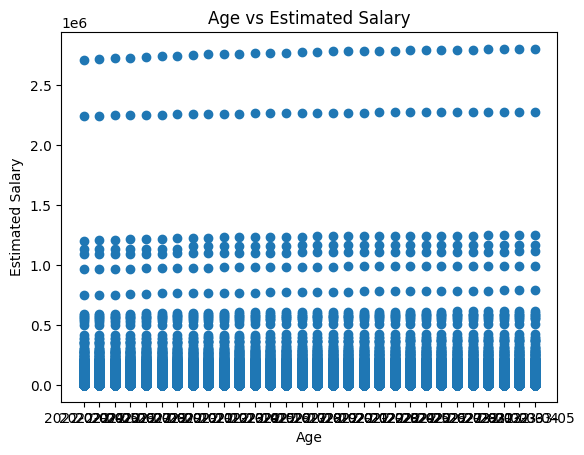

In [6]:
plt.figure()
plt.scatter(df['date'], df['cases'])
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.title('Age vs Estimated Salary')
plt.show()

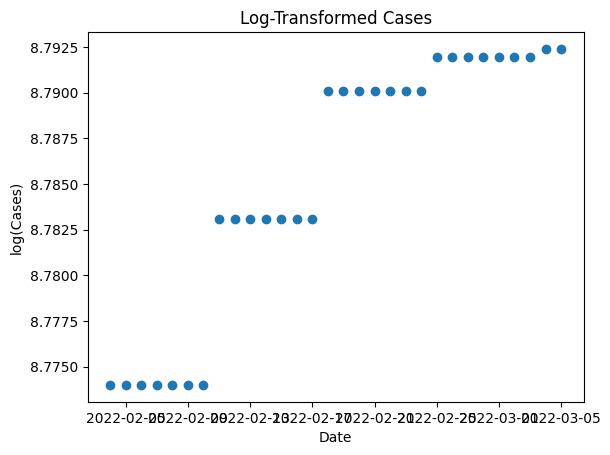

In [7]:
import numpy as np

plt.figure()
plt.scatter(pd.to_datetime(county_df['date']),
         np.log(county_df['cases'] + 1))
plt.xlabel('Date')
plt.ylabel('log(Cases)')
plt.title('Log-Transformed Cases')
plt.show()


In [8]:
county_df['date'] = pd.to_datetime(county_df['date'])


/tmp/ipython-input-354067181.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  county_df['date'] = pd.to_datetime(county_df['date'])


In [9]:
county_df['day'] = (county_df['date'] - county_df['date'].min()).dt.days


/tmp/ipython-input-25774850.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  county_df['day'] = (county_df['date'] - county_df['date'].min()).dt.days


In [14]:
import numpy as np

y_log = np.log(y + 1)

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y_log)

LinearRegression()

In [16]:
y_pred_log = model.predict(X)
y_pred_exp = np.exp(y_pred_log)


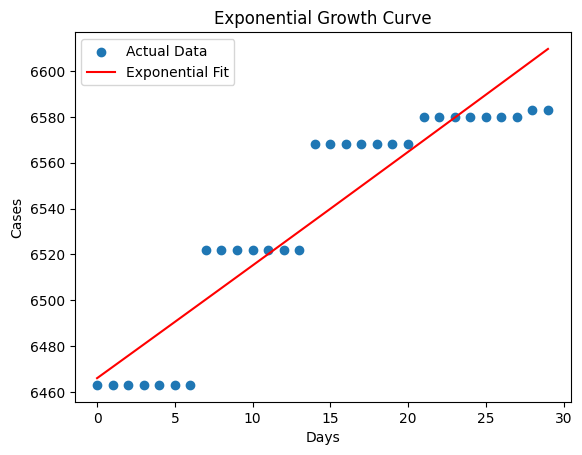

In [17]:
plt.scatter(X, y, label="Actual Data")
plt.plot(X, y_pred_exp, color='red', label="Exponential Fit")
plt.xlabel("Days")
plt.ylabel("Cases")
plt.title("Exponential Growth Curve")
plt.legend()
plt.show()

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = county_df[['day']]
y = county_df['cases']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
print("MSE:", mse)


MSE: 292.98904461747736


In [11]:
y_log = np.log(y + 1)
model.fit(X, y_log)
y_log_pred = model.predict(X)

mse_log = mean_squared_error(y_log, y_log_pred)
print("MSE after log transform:", mse_log)


MSE after log transform: 6.931729565839243e-06


In [12]:
future_days = np.array([[35], [40], [45], [50]])

future_log = model.predict(future_days)
future_cases = np.exp(future_log)

for d, c in zip(future_days.flatten(), future_cases):
    print(f"Day {d}: Predicted cases ≈ {int(c)}")


Day 35: Predicted cases ≈ 6639
Day 40: Predicted cases ≈ 6665
Day 45: Predicted cases ≈ 6690
Day 50: Predicted cases ≈ 6715


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [18]:
# Predicting more future values
future_days = np.array([[35], [40], [45], [50], [55], [60]])

future_log_pred = model.predict(future_days)
future_cases = np.exp(future_log_pred)

prediction_df = pd.DataFrame({
    "Future Day": future_days.flatten(),
    "Predicted Cases": future_cases.astype(int)
})

prediction_df


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Future Day,Predicted Cases
0,35,6639
1,40,6665
2,45,6690
3,50,6715
4,55,6741
5,60,6766


The given dataset shows non-linear behavior. After preprocessing and applying logarithmic transformation, the data was identified to follow exponential growth. An exponential regression model was trained and evaluated using Mean Squared Error. The model was further used to predict future values, showing a consistent growth trend.